In [113]:
# More Decreasing Homicide Analysis
# Anita Sun

In [114]:
import pandas as pd
import geopandas as gpd
import shapely
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
import re
from shapely.wkt import loads
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [115]:
wave_metrics = pd.read_csv('wave_metrics.csv')
map_data = gpd.read_file('map_data.csv')
map_projects = gpd.read_file('map_projects.csv')
outliers = gpd.read_file('gap_outliers.csv')
top_amp = gpd.read_file('wave_amp_outliers.csv')
shapefile = gpd.read_file('Jada_Hexagons/hex_hom_bldg.shp')

In [116]:
map_data.geometry = map_data.geometry.apply(loads)
map_data = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:4326")
outliers.geometry = outliers.geometry.apply(loads)
outliers = gpd.GeoDataFrame(outliers, geometry='geometry', crs="EPSG:4326")
top_amp.geometry = top_amp.geometry.apply(loads)
top_amp = gpd.GeoDataFrame(top_amp, geometry='geometry', crs="EPSG:4326")

In [117]:
commarea = gpd.read_file('comm_area_shapefiles/CHI Community Areas.shp')
commarea.geometry = commarea.geometry.to_crs(epsg=4326)

In [118]:
project_shapefile = gpd.read_file('cha_projects.geojson')

In [119]:
project_shapefile.head()

,name,yr_built_start,yr_built_end,yr_dmlsh_or_cnvrt_start,yr_dmlsh_or_cnvrt_end,units,id,geometry
0,Julia Lathrop,1938,NaN,2012.0,NaN,925,None,POINT (-87.67814 41.93229)
1,Cabrini Green,1942,NaN,1995.0,2010.0,3500,None,POINT (-87.64008 41.90046)
2,Henry Horner,1957,1963.0,1995.0,2008.0,920,None,POINT (-87.6767 41.8841)
3,Rockwell Gardens,1959,NaN,2000.0,2006.0,1126,None,POINT (-87.68938 41.87666)
4,Hilliard Towers,1966,NaN,2006.0,NaN,654,None,POINT (-87.63015 41.8552)


In [120]:
map_projects = map_data.sjoin(project_shapefile, how='inner')

In [121]:
wave_metrics.head()

,Unnamed: 0,GRID_ID,wave_group,wave_lifespan,wave_amplitude,wave_start_year,wave_decade,wave_end_year,max_amp,min_amp
0,0,AA-10,1,1,3,1928,1920,1929,6,3
1,1,AA-10,2,1,5,1975,1970,1976,6,3
2,2,AA-10,3,2,5,1980,1980,1982,6,3
3,3,AA-10,4,2,4,1984,1980,1986,6,3
4,4,AA-10,5,5,6,1989,1980,1994,6,3


In [122]:
map_projects.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap,index_right,name,yr_built_start,yr_built_end,yr_dmlsh_or_cnvrt_start,yr_dmlsh_or_cnvrt_end,units,id
17,17,AM-36,1874,0.0,0.0,,"POLYGON ((-87.59165 41.65495, -87.59466 41.649...",2007.0,10.0,16,Altgeld Gardens,1945,NaN,NaN,NaN,1500,None
139,139,AI-29,1874,0.0,0.0,,"POLYGON ((-87.6277 41.72779, -87.63071 41.7225...",1994.0,23.0,14,Lowden Homes,1952,NaN,NaN,NaN,127,None
279,279,AJ-21,1874,0.0,0.0,,"POLYGON ((-87.61869 41.81624, -87.62169 41.811...",2012.0,5.0,13,Robert Taylor,1961,NaN,1998.0,2007.0,4415,None
293,293,AI-20,1874,0.0,3.80644355802387,0.0,"POLYGON ((-87.6277 41.82145, -87.63071 41.8162...",2017.0,0.0,9,Wentworth Gardens,1945,NaN,NaN,NaN,344,None
294,294,AJ-20,1874,0.0,4.735893981097023,0.0,"POLYGON ((-87.61869 41.82665, -87.62169 41.821...",2015.0,2.0,10,Stateway Gardens,1955,1958.0,2001.0,2007.0,1644,None


In [123]:
map_projects['longest_gap'] = map_projects['longest_gap'].astype(float)

In [124]:
for col in map_projects.columns:
    try:
        map_projects[col] = map_projects[col].astype(float)
    except:
        pass

In [125]:
map_projects['yr_dmlsh_or_cnvrt_end'].value_counts()

yr_dmlsh_or_cnvrt_end
2007.0    268
2011.0    268
2006.0    134
2008.0    134
2010.0    134
Name: count, dtype: int64

In [126]:
map_projects['last_wave_end'].mode()

0    1994.0
Name: last_wave_end, dtype: float64

In [127]:
np.float64('nan')

np.float64(nan)

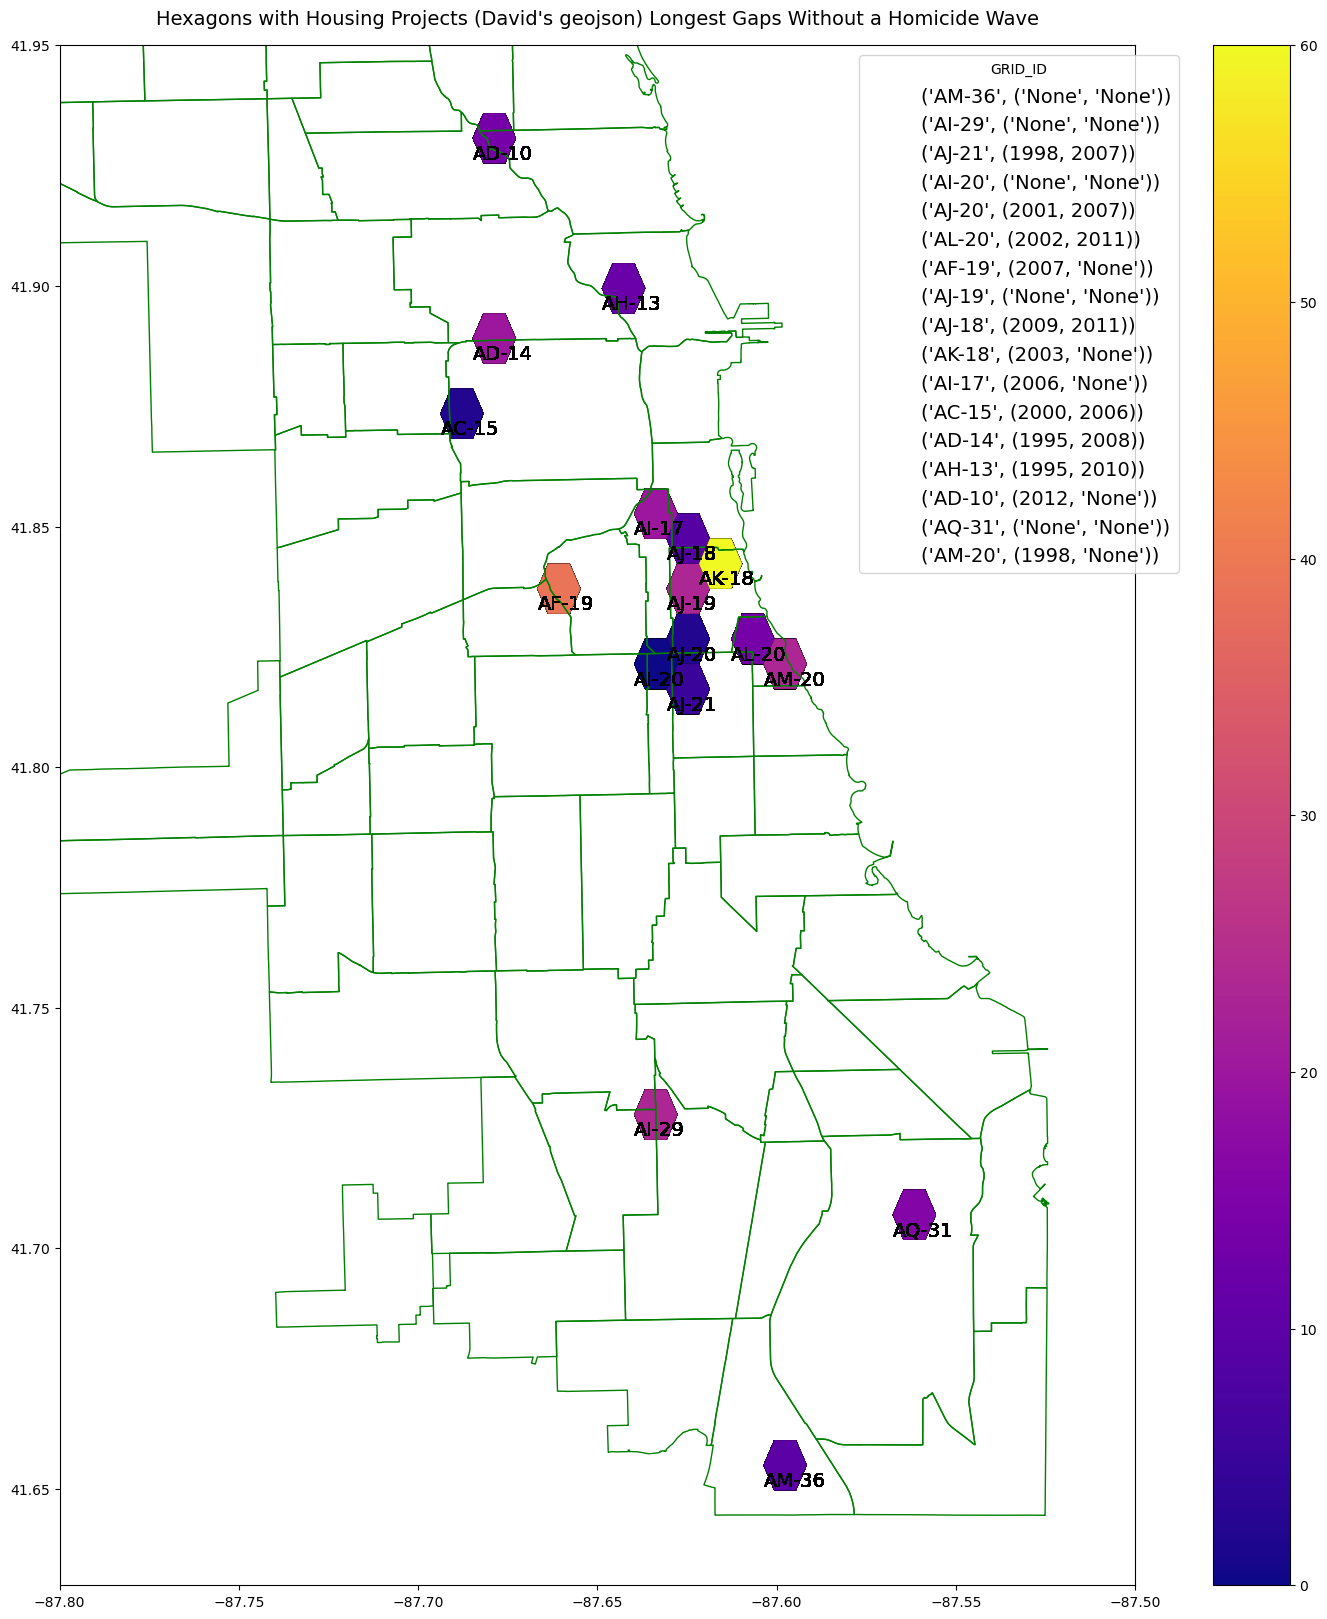

In [128]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(20, 20))

# Plot all hexagons colored by longest_gap
map_projects.plot(column="longest_gap", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with Housing Projects (David's geojson) Longest Gaps Without a Homicide Wave", fontsize=14, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

plt.xlim(-87.8, -87.5)
plt.ylim(41.63, 41.95)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels

for geo, label in zip(map_projects.geometry,
                        map_projects.GRID_ID):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, label, 
             fontsize=14, color='black' , ha="left", va="bottom", weight="normal", wrap=True)
'''
for x, y, label in zip(commarea.geometry.centroid.x, 
                        commarea.geometry.centroid.y, 
                        commarea["COMMUNITY"]):
    ax.text(x, y, label, fontsize=6, color="white", ha="center", va="center")'''

legend = []

for i in map_projects['GRID_ID'].unique():
    sub_map = map_projects[map_projects['GRID_ID']==i]
    dmlsh_start = sub_map['yr_dmlsh_or_cnvrt_start'].max()
    dmlsh_start = 'None' if np.isnan(dmlsh_start) else int(dmlsh_start)
    dmlsh_end = sub_map['yr_dmlsh_or_cnvrt_end'].max()
    dmlsh_end = 'None' if np.isnan(dmlsh_end) else int(dmlsh_end)

    legend.append((i, (dmlsh_start, dmlsh_end)))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=14, title="GRID_ID", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.savefig('viz/projects_longest_gaps_real.png')

plt.show()

### Wave Intensity

In [129]:
wave_metrics.head()

,Unnamed: 0,GRID_ID,wave_group,wave_lifespan,wave_amplitude,wave_start_year,wave_decade,wave_end_year,max_amp,min_amp
0,0,AA-10,1,1,3,1928,1920,1929,6,3
1,1,AA-10,2,1,5,1975,1970,1976,6,3
2,2,AA-10,3,2,5,1980,1980,1982,6,3
3,3,AA-10,4,2,4,1984,1980,1986,6,3
4,4,AA-10,5,5,6,1989,1980,1994,6,3


In [130]:
scaler = RobustScaler()
normalized = scaler.fit_transform(wave_metrics['wave_amplitude'].values.reshape(-1, 1))
wave_metrics['wave_amp_normal'] = normalized

In [131]:
wave_metrics['wave_intensity'] = wave_metrics.apply(
    lambda x: x['wave_amp_normal'] / x['wave_lifespan'],
    axis=1
)

In [132]:
wave_metrics.nlargest(10, 'wave_intensity')

,Unnamed: 0,GRID_ID,wave_group,wave_lifespan,wave_amplitude,wave_start_year,wave_decade,wave_end_year,max_amp,min_amp,wave_amp_normal,wave_intensity
842,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0
1316,1316,AH-27,1317,1,11,1991,1990,1992,11,3,3.5,3.5
1451,1451,AI-18,1452,1,11,1930,1930,1931,11,3,3.5,3.5
509,509,AE-15,510,1,10,1928,1920,1929,10,3,3.0,3.0
691,691,AF-15,692,1,10,1930,1930,1931,10,3,3.0,3.0
908,908,AG-13,909,1,10,1947,1940,1948,14,3,3.0,3.0
350,350,AD-13,351,1,9,1971,1970,1972,9,3,2.5,2.5
696,696,AF-15,697,1,9,1970,1970,1971,10,3,2.5,2.5
910,910,AG-13,911,2,14,1954,1950,1956,14,3,5.0,2.5
2208,2208,AN-26,2209,1,9,1997,1990,1998,9,3,2.5,2.5


<Axes: xlabel='wave_intensity'>

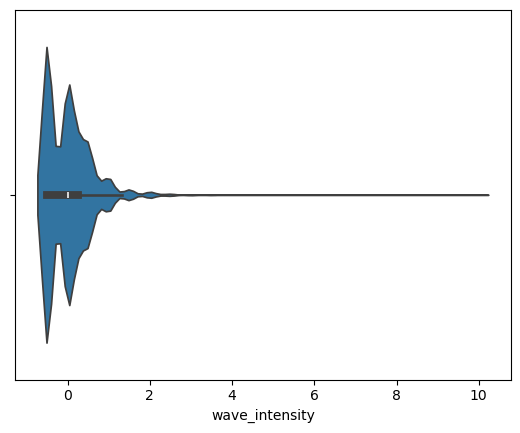

In [133]:
sns.violinplot(wave_metrics,
            x='wave_intensity')

In [134]:
map_data_intensity = pd.merge(left=wave_metrics.nlargest(20, columns=['wave_intensity',
                                                                      'wave_amplitude',
                                                                      ]
                                                                      ),
                              right=map_data,
                              how='inner',
                              on='GRID_ID'
                              )

In [135]:
map_data_intensity = gpd.GeoDataFrame(
    map_data_intensity,
    geometry='geometry',
)

In [136]:
map_data_intensity.head()

,Unnamed: 0,GRID_ID,wave_group,wave_lifespan,wave_amplitude,wave_start_year,wave_decade,wave_end_year,max_amp,min_amp,wave_amp_normal,wave_intensity,field_1,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap
0,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0,638,1874,0.0,0.745646572751469,0.0,"POLYGON ((-87.65474 41.99314, -87.65774 41.987...",2001.0,16.0
1,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0,1459,1875,0.0,0.932058215939337,0.0,"POLYGON ((-87.65474 41.99314, -87.65774 41.987...",2001.0,16.0
2,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0,2280,1876,0.0,0.932058215939337,0.0,"POLYGON ((-87.65474 41.99314, -87.65774 41.987...",2001.0,16.0
3,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0,3101,1877,0.0,0.932058215939337,0.0,"POLYGON ((-87.65474 41.99314, -87.65774 41.987...",2001.0,16.0
4,842,AF-4,843,1,24,1976,1970,1977,24,3,10.0,10.0,3922,1878,0.0,0.932058215939337,0.0,"POLYGON ((-87.65474 41.99314, -87.65774 41.987...",2001.0,16.0


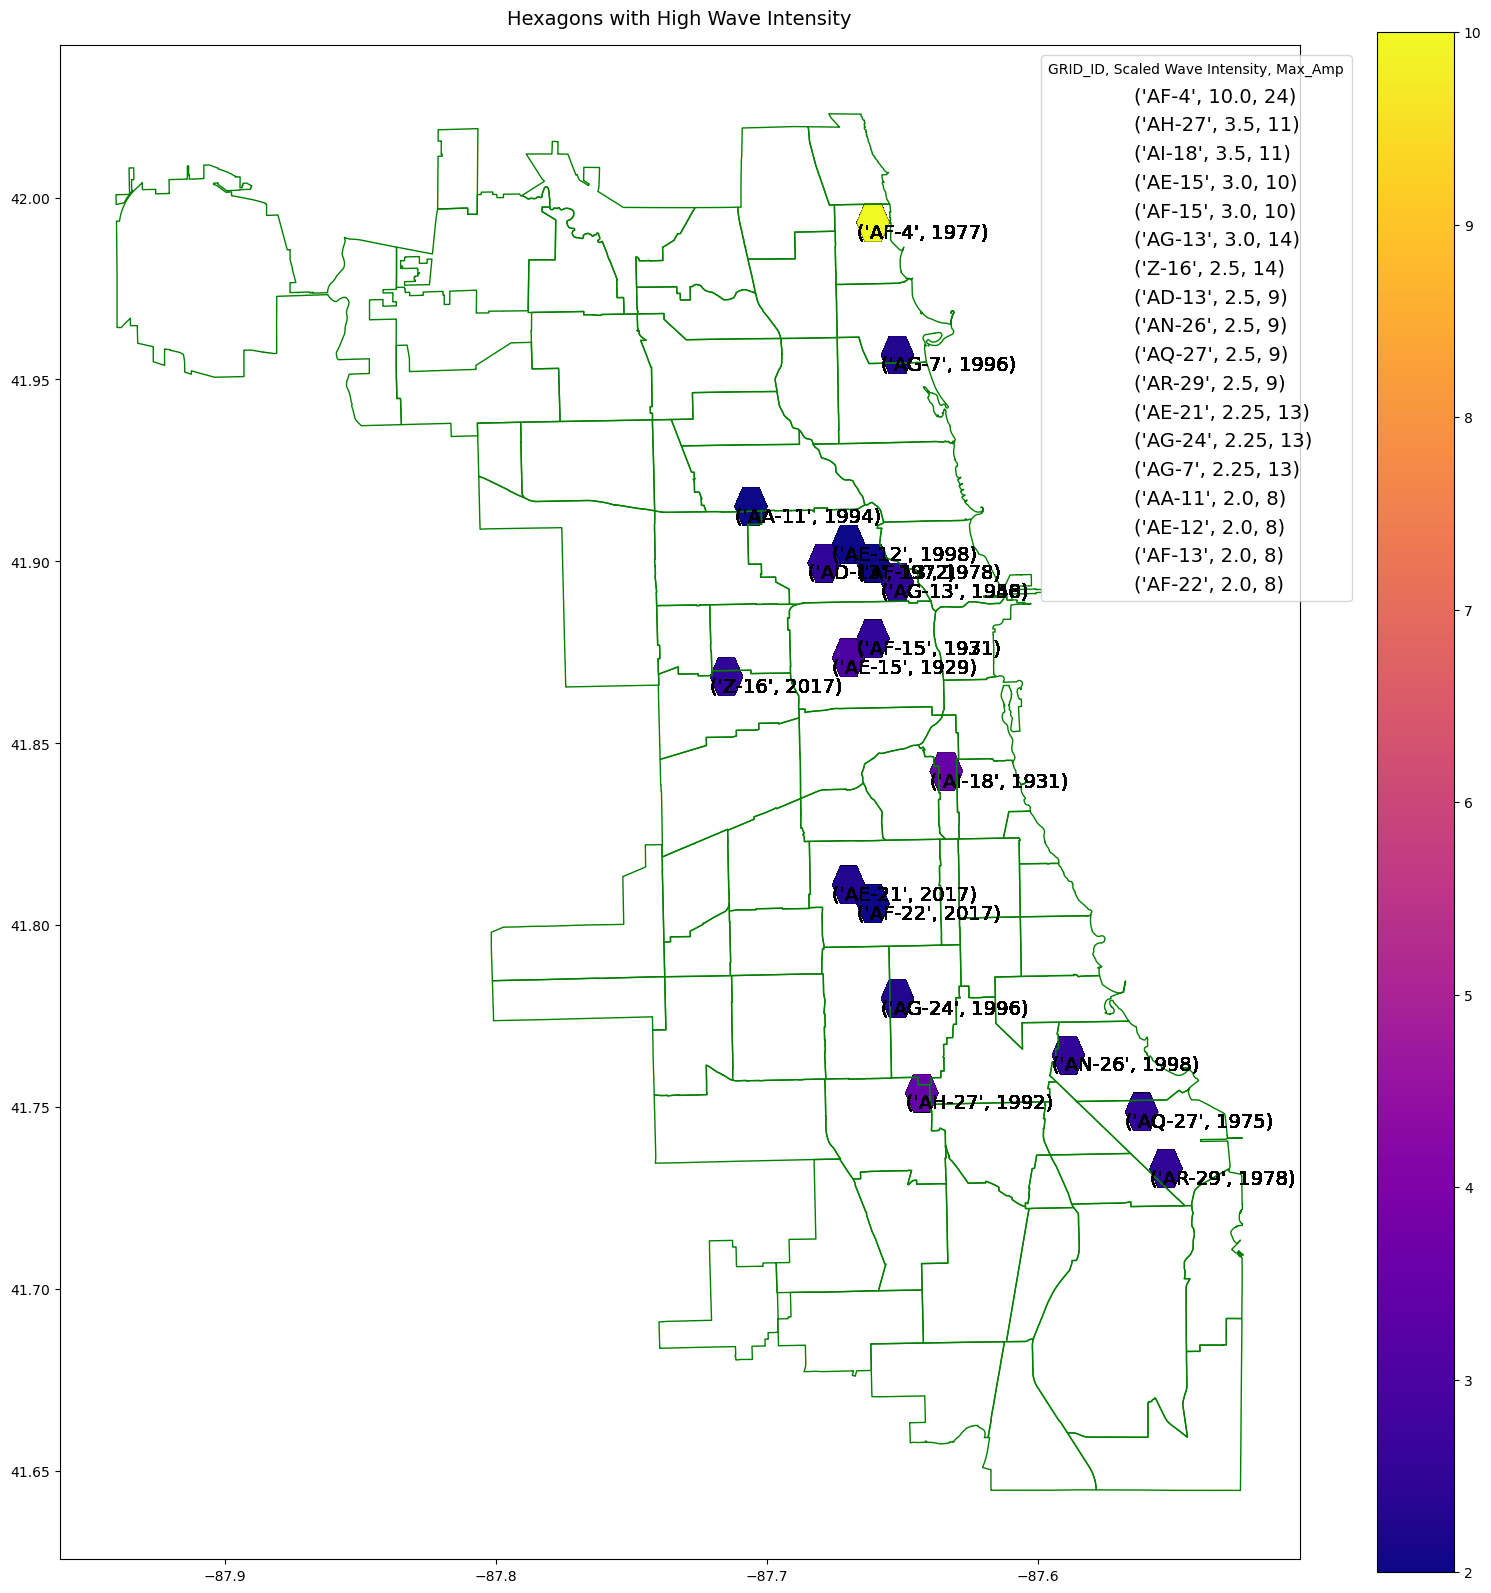

In [137]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(20, 20))

# Plot all hexagons colored by longest_gap
map_data_intensity.plot(column="wave_intensity", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with High Wave Intensity", fontsize=14, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

#plt.xlim(-87.8, -87.5)
#plt.ylim(41.63, 41.95)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels

for geo, label, year in zip(map_data_intensity.geometry,
                        map_data_intensity.GRID_ID,
                        map_data_intensity.wave_end_year):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, (label, year),
             fontsize=14, color='black' , ha="left", va="bottom", weight="normal", wrap=True)
'''
for x, y, label in zip(commarea.geometry.centroid.x, 
                        commarea.geometry.centroid.y, 
                        commarea["COMMUNITY"]):
    ax.text(x, y, label, fontsize=6, color="white", ha="center", va="center")'''

legend = []

for i in map_data_intensity['GRID_ID'].unique():
    sub_map = map_data_intensity[map_data_intensity['GRID_ID']==i]
    amp = sub_map['wave_amplitude'].max()
    intensity = sub_map['wave_intensity'].max()

    legend.append((i, float(intensity), int(amp)))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=14, title="GRID_ID, Scaled Wave Intensity, Max_Amp", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.show()

In [138]:
map_data.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap
0,0,AJ-37,1874,0.0,0.0,,"POLYGON ((-87.61869 41.64975, -87.62169 41.644...",,
1,1,AK-37,1874,0.0,4.198222705933977,0.0,"POLYGON ((-87.60968 41.64454, -87.61268 41.639...",,
2,2,AL-37,1874,0.0,0.001777294066012,0.0,"POLYGON ((-87.60067 41.64975, -87.60367 41.644...",1996.0,21.0
3,3,AM-37,1874,0.0,0.0,,"POLYGON ((-87.59165 41.64454, -87.59466 41.639...",,
4,4,AN-37,1874,0.0,0.0,,"POLYGON ((-87.58264 41.64975, -87.58565 41.644...",,


In [139]:
map_data['year'] = map_data['year'].astype(int)
map_data['hom_ct'] = map_data['hom_ct'].astype(float)

In [202]:
def dropoff(df, num_year):

    df_future = df.copy()
    df_future['year'] += num_year  # Shift years backwards to align future values
    df_future = df_future.rename(columns={'hom_ct': 'past_hom_ct'})  # Rename column for clarity

    # Merge original df with shifted df
    df_merged = df.merge(df_future[['GRID_ID', 'year', 'past_hom_ct']], 
                          on=['GRID_ID', 'year'], 
                          how='left')

    # Compute the difference (increase → negative, decrease → positive)
    df_merged[f'dropoff_{num_year}year'] = df_merged['past_hom_ct'] - df_merged['hom_ct']
    df_merged.drop(columns=['past_hom_ct'], inplace=True)
    return df_merged

In [157]:
def detect_outliers_pandas(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return series[series > upper_bound]

In [142]:
map_data.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap
0,0,AJ-37,1874,0.0,0.0,,"POLYGON ((-87.61869 41.64975, -87.62169 41.644...",,
1,1,AK-37,1874,0.0,4.198222705933977,0.0,"POLYGON ((-87.60968 41.64454, -87.61268 41.639...",,
2,2,AL-37,1874,0.0,0.001777294066012,0.0,"POLYGON ((-87.60067 41.64975, -87.60367 41.644...",1996.0,21.0
3,3,AM-37,1874,0.0,0.0,,"POLYGON ((-87.59165 41.64454, -87.59466 41.639...",,
4,4,AN-37,1874,0.0,0.0,,"POLYGON ((-87.58264 41.64975, -87.58565 41.644...",,


In [203]:
map_data = dropoff(map_data, 1)
map_data = dropoff(map_data, 5)
map_data = dropoff(map_data, 10)

In [204]:
map_data_oneyear = map_data.nlargest(15, 'dropoff_1year')
map_data_fiveyear = map_data.nlargest(15, 'dropoff_5year')
map_data_tenyear = map_data.nlargest(15, 'dropoff_10year')

In [205]:
map_data_oneyear['GRID_ID'].nunique()

11

In [206]:
len(detect_outliers_pandas(map_data['dropoff_1year']))

11654

In [207]:
map_data.dropoff_1year.describe()

count    108372.000000
mean         -0.010722
std           1.033491
min         -23.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          23.000000
Name: dropoff_1year, dtype: float64

/tmp/ipykernel_73272/3943721818.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(commarea_intersecting.geometry.centroid.x,
/tmp/ipykernel_73272/3943721818.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  commarea_intersecting.geometry.centroid.y,


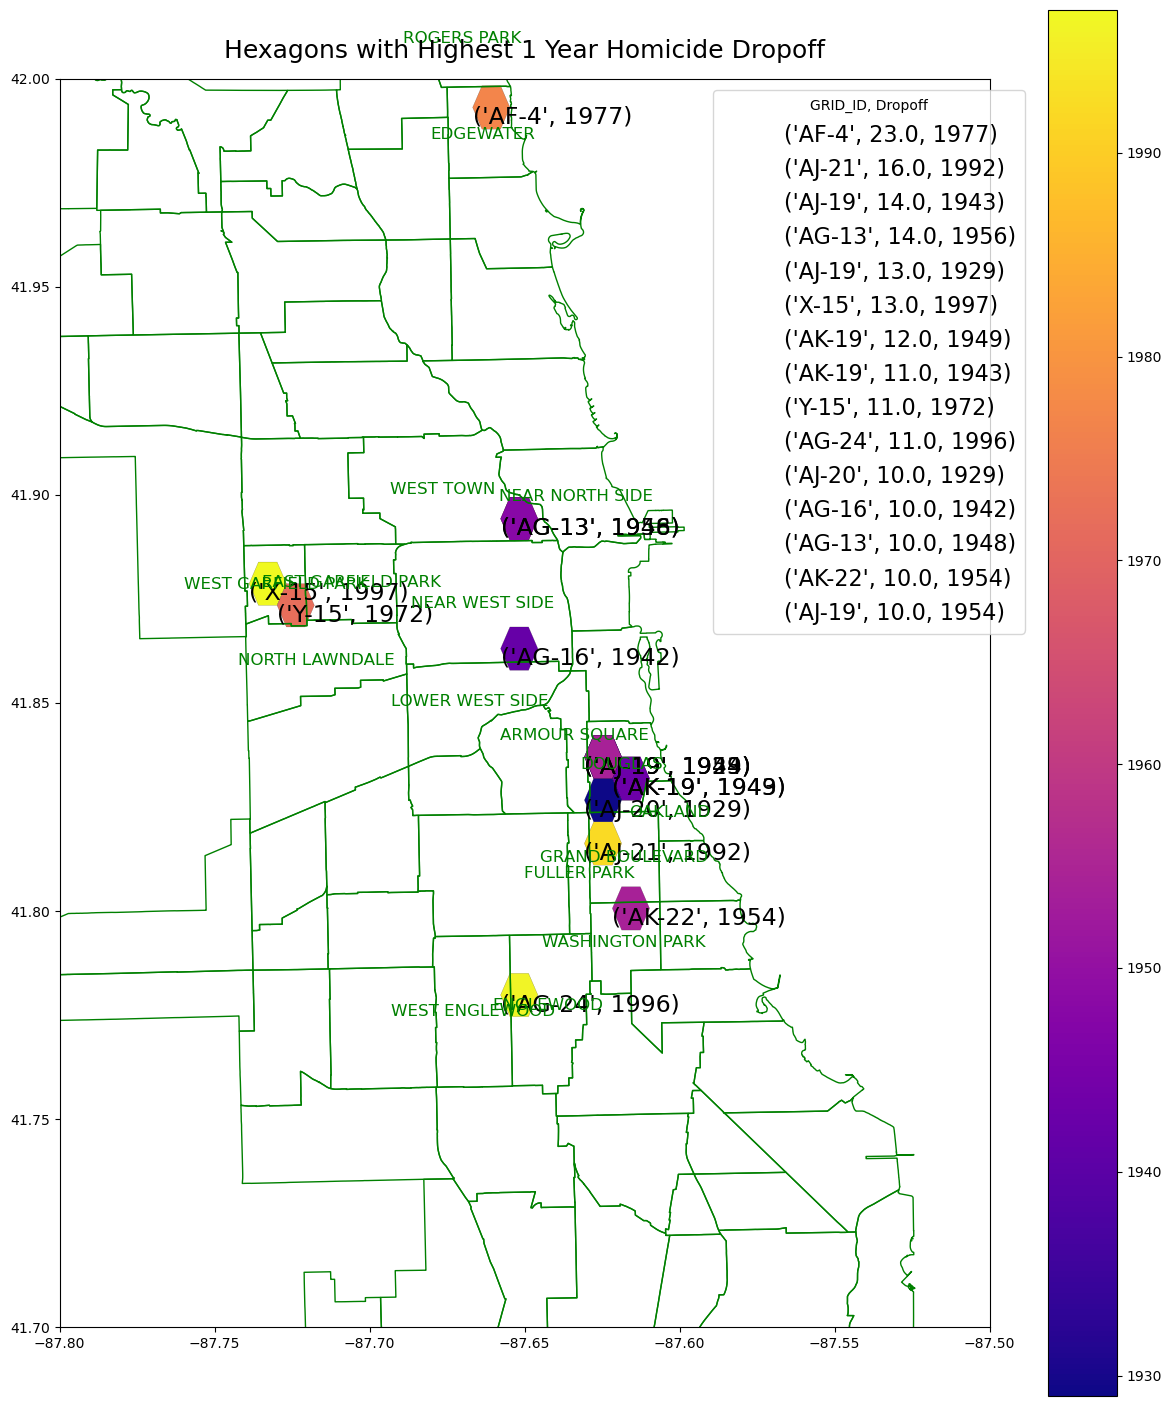

In [215]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 18))

# Plot all hexagons colored by longest_gap
map_data_oneyear.plot(column="year", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with Highest 1 Year Homicide Dropoff", fontsize=18, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

plt.xlim(-87.8, -87.5)
plt.ylim(41.7, 42.00)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels

for geo, label, year in zip(map_data_oneyear.geometry,
                        map_data_oneyear.GRID_ID,
                        map_data_oneyear.year):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, (label, year),
             fontsize=17, color='black' , ha="left", va="bottom", weight="normal", wrap=True)
    
commarea_intersecting = commarea[commarea.geometry.apply(lambda g: map_data_oneyear.geometry.intersects(g).any())]

# Add labels for only the intersecting communities
for x, y, label in zip(commarea_intersecting.geometry.centroid.x, 
                        commarea_intersecting.geometry.centroid.y, 
                        commarea_intersecting["COMMUNITY"]):
    ax.text(x, y, label, fontsize=12, color="green", ha="center", va="center", wrap=True)


legend = []

for i, dropoff, year in zip(map_data_oneyear['GRID_ID'], map_data_oneyear.dropoff_1year, map_data_oneyear.year):
    legend.append((i, dropoff, year))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=16, title="GRID_ID, Dropoff", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.show()

/tmp/ipykernel_73272/902628876.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(commarea_intersecting.geometry.centroid.x,
/tmp/ipykernel_73272/902628876.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  commarea_intersecting.geometry.centroid.y,


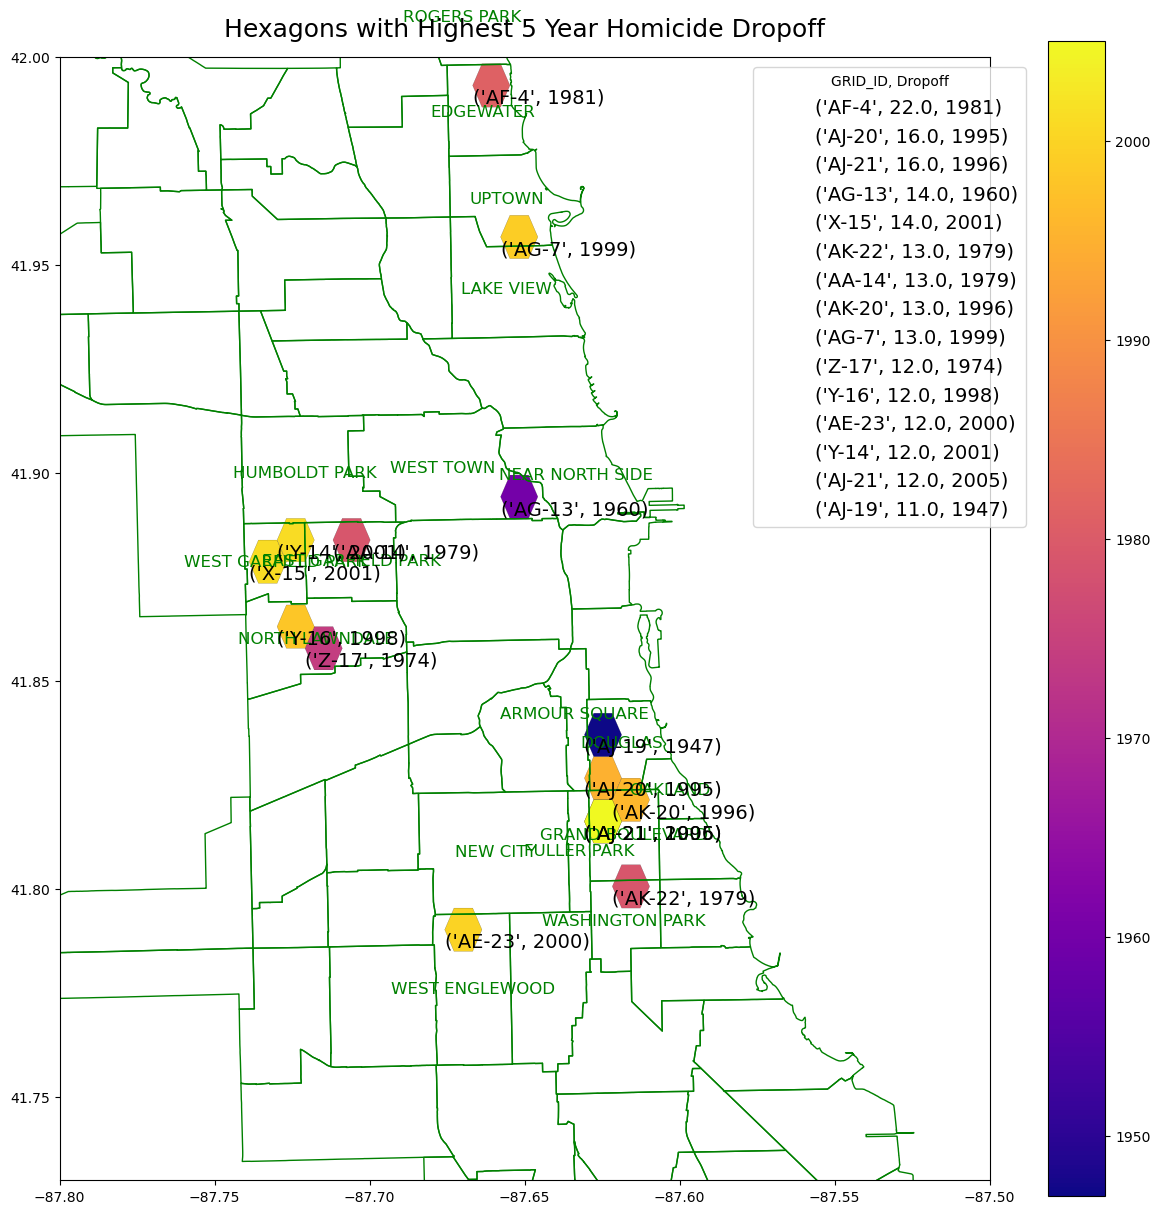

In [216]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 15))

# Plot all hexagons colored by longest_gap
map_data_fiveyear.plot(column="year", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with Highest 5 Year Homicide Dropoff", fontsize=18, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

plt.xlim(-87.8, -87.5)
plt.ylim(41.73, 42.00)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels
commarea_intersecting = commarea[commarea.geometry.apply(lambda g: map_data_fiveyear.geometry.intersects(g).any())]

# Add labels for only the intersecting communities
for x, y, label in zip(commarea_intersecting.geometry.centroid.x, 
                        commarea_intersecting.geometry.centroid.y, 
                        commarea_intersecting["COMMUNITY"]):
    ax.text(x, y, label, fontsize=12, color="green", ha="center", va="center", wrap=True)

for geo, label, year in zip(map_data_fiveyear.geometry,
                        map_data_fiveyear.GRID_ID,
                        map_data_fiveyear.year):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, (label, year),
             fontsize=14, color='black' , ha="left", va="bottom", weight="normal", wrap=True)

legend = []

for i, dropoff, year in zip(map_data_fiveyear['GRID_ID'], map_data_fiveyear.dropoff_5year, map_data_fiveyear.year):
    legend.append((i, dropoff, year))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=14, title="GRID_ID, Dropoff", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.show()

/tmp/ipykernel_73272/49603035.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(commarea_intersecting.geometry.centroid.x,
/tmp/ipykernel_73272/49603035.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  commarea_intersecting.geometry.centroid.y,


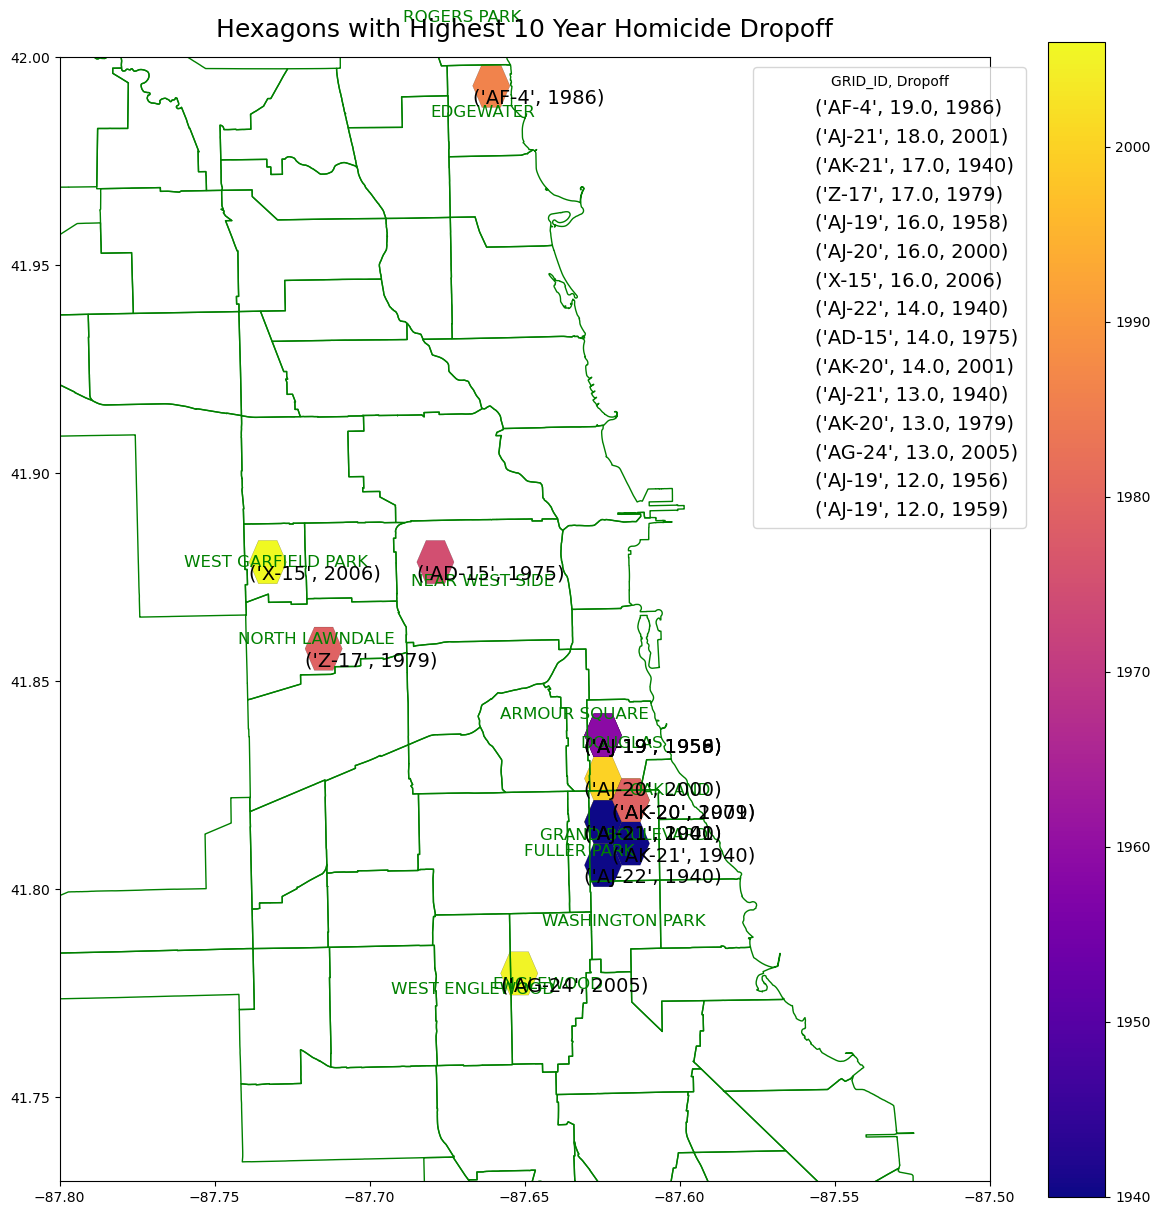

In [217]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 15))

# Plot all hexagons colored by longest_gap
map_data_tenyear.plot(column="year", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with Highest 10 Year Homicide Dropoff", fontsize=18, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

plt.xlim(-87.8, -87.5)
plt.ylim(41.73, 42.00)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels
commarea_intersecting = commarea[commarea.geometry.apply(lambda g: map_data_tenyear.geometry.intersects(g).any())]

# Add labels for only the intersecting communities
for x, y, label in zip(commarea_intersecting.geometry.centroid.x, 
                        commarea_intersecting.geometry.centroid.y, 
                        commarea_intersecting["COMMUNITY"]):
    ax.text(x, y, label, fontsize=12, color="green", ha="center", va="center", wrap=True)

for geo, label, year in zip(map_data_tenyear.geometry,
                        map_data_tenyear.GRID_ID,
                        map_data_tenyear.year):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, (label, year),
             fontsize=14, color='black' , ha="left", va="bottom", weight="normal", wrap=True)

legend = []

for i, dropoff, year in zip(map_data_tenyear['GRID_ID'], map_data_tenyear.dropoff_10year, map_data_tenyear.year):
    legend.append((i, dropoff, year))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=14, title="GRID_ID, Dropoff", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.show()